In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.model_selection import train_test_split,GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("Video_Games_Sales_Cleaned.csv")

In [4]:
df.head()

,title,console,genre,publisher,developer,critic_score,total_sales,release_year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,2013.0
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,2014.0
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,2002.0
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.3,15.86,2013.0
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,2015.0


In [5]:
df.shape

(18832, 8)

In [6]:
df.isna().sum()

title           0
console         0
genre           0
publisher       0
developer       0
critic_score    0
total_sales     0
release_year    0
dtype: int64

In [7]:
df['publisher'].value_counts()

publisher
Activision                     1044
Ubisoft                        1012
Electronic Arts                 843
Konami                          769
THQ                             726
                               ... 
Noviy Disk                        1
Joindots                          1
United Developers                 1
Stack                             1
Digital Works Entertainment       1
Name: count, Length: 739, dtype: int64

In [8]:
df['developer'].value_counts()

developer
Unknown                                         432
Konami                                          407
Capcom                                          293
EA Canada                                       292
Bandai Namco Games                              209
                                               ... 
Noise                                             1
Digital Works Entertainment                       1
Snowberry Connection and Sich Studio              1
Sigil Games Online/Sony Online Entertainment      1
TownFactory                                       1
Name: count, Length: 2857, dtype: int64

In [9]:
df['console'].value_counts()

console
DS      2376
PS2     2120
PC      1549
Wii     1345
PS3     1340
PSP     1329
X360    1294
PS      1129
PS4      908
GBA      898
XB       836
PSV      678
3DS      560
GC       526
XOne     524
N64      277
NS       262
SNES     197
SAT      175
WiiU     148
2600     125
DC        49
NES       47
GB        46
GEN       27
PSN       14
NG        12
XBL        8
WS         7
VC         6
SCD        5
3DO        4
GBC        3
WW         2
PCE        2
GG         1
OSX        1
Mob        1
PCFX       1
Name: count, dtype: int64

In [10]:
df = df.drop('title',axis=1)

In [11]:
df.head()

,console,genre,publisher,developer,critic_score,total_sales,release_year
0,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,2013.0
1,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,2014.0
2,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,2002.0
3,X360,Action,Rockstar Games,Rockstar North,7.3,15.86,2013.0
4,PS4,Shooter,Activision,Treyarch,8.1,15.09,2015.0


In [12]:
df[df['total_sales']==0]

,console,genre,publisher,developer,critic_score,total_sales,release_year
17508,PSV,Visual Novel,Aksys Games,ChunSoft,7.3,0.0,2012.0
17509,NS,Visual Novel,Aria,August,7.3,0.0,2018.0
17510,NS,Visual Novel,Idea Factory,Otomate,7.3,0.0,2018.0
17511,PSV,Visual Novel,Dramatic Create,girls dynamics,7.3,0.0,2018.0
17512,PS4,Visual Novel,Prototype,Prototype,7.3,0.0,2018.0
...,...,...,...,...,...,...,...
18827,WiiU,Platform,Rain Games,Rain Games,7.0,0.0,2014.0
18828,XB,Platform,Ubisoft,Ubisoft Montreal,6.4,0.0,2006.0
18829,PC,Platform,THQ,Heavy Iron Studios,6.0,0.0,2004.0
18830,GBA,Platform,Telegames,Ivolgamus UAB,7.3,0.0,2002.0


In [13]:
(df['total_sales']==0).sum()

np.int64(1324)

In [14]:
null_sales_id = df[df['total_sales']==0].index

In [15]:
df.drop(null_sales_id,inplace=True)

In [16]:
df.head()

,console,genre,publisher,developer,critic_score,total_sales,release_year
0,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,2013.0
1,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,2014.0
2,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,2002.0
3,X360,Action,Rockstar Games,Rockstar North,7.3,15.86,2013.0
4,PS4,Shooter,Activision,Treyarch,8.1,15.09,2015.0


In [17]:
(df['critic_score']==0).sum()

np.int64(0)

In [18]:
df.shape

(17508, 7)

<Axes: xlabel='console', ylabel='percent'>

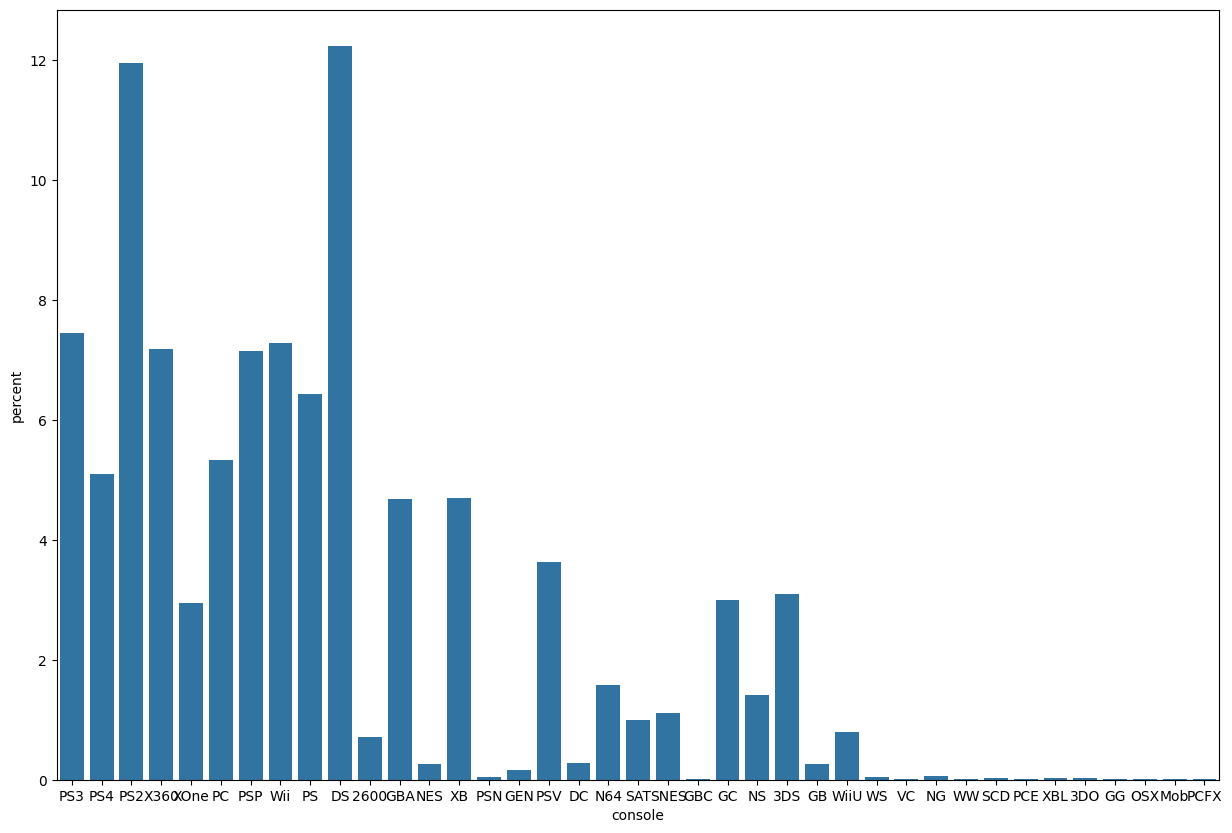

In [19]:
plt.figure(figsize=(15,10))
sns.countplot(df,x='console',stat="percent")

<Axes: xlabel='critic_score', ylabel='total_sales'>

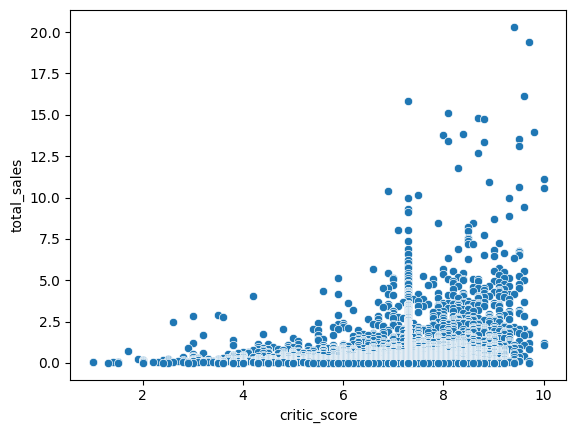

In [20]:
sns.scatterplot(data=df,x='critic_score',y='total_sales')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43],
 [Text(0, 0, '1977.0'),
  Text(1, 0, '1978.0'),
  Text(2, 0, '1979.0'),
  Text(3, 0, '1980.0'),
  Text(4, 0, '1981.0'),
  Text(5, 0, '1982.0'),
  Text(6, 0, '1983.0'),
  Text(7, 0, '1984.0'),
  Text(8, 0, '1985.0'),
  Text(9, 0, '1986.0'),
  Text(10, 0, '1987.0'),
  Text(11, 0, '1988.0'),
  Text(12, 0, '1989.0'),
  Text(13, 0, '1990.0'),
  Text(14, 0, '1991.0'),
  Text(15, 0, '1992.0'),
  Text(16, 0, '1993.0'),
  Text(17, 0, '1994.0'),
  Text(18, 0, '1995.0'),
  Text(19, 0, '1996.0'),
  Text(20, 0, '1997.0'),
  Text(21, 0, '1998.0'),
  Text(22, 0, '1999.0'),
  Text(23, 0, '2000.0'),
  Text(24, 0, '2001.0'),
  Text(25, 0, '2002.0'),
  Text(26, 0, '2003.0'),
  Text(27, 0, '2004.0'),
  Text(28, 0, '2005.0'),
  Text(29, 0, '2006.0'),
  Tex

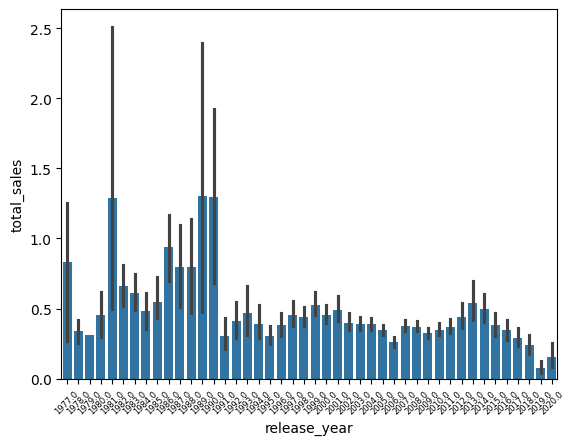

In [21]:
sns.barplot(data=df,y='total_sales',x='release_year')
plt.xticks(rotation=45, fontsize=6)

In [22]:
df.describe()

,critic_score,total_sales,release_year
count,17508.000000,17508.000000,17508.000000
mean,7.255695,0.376932,2007.669865
std,0.687713,0.833100,6.129213
min,1.000000,0.010000,1977.000000
25%,7.300000,0.050000,2004.000000
50%,7.300000,0.140000,2008.000000
75%,7.300000,0.380000,2011.000000
max,10.000000,20.320000,2020.000000


In [23]:
df.columns

Index(['console', 'genre', 'publisher', 'developer', 'critic_score',
       'total_sales', 'release_year'],
      dtype='str')

In [24]:
df.dtypes

console             str
genre               str
publisher           str
developer           str
critic_score    float64
total_sales     float64
release_year    float64
dtype: object

In [25]:
y = df['total_sales']

In [26]:
y

0        20.32
1        19.39
2        16.15
3        15.86
4        15.09
         ...  
17503     0.01
17504     0.01
17505     0.01
17506     0.01
17507     0.01
Name: total_sales, Length: 17508, dtype: float64

In [27]:
x = df.drop('total_sales',axis=1)

In [28]:
x

,console,genre,publisher,developer,critic_score,release_year
0,PS3,Action,Rockstar Games,Rockstar North,9.4,2013.0
1,PS4,Action,Rockstar Games,Rockstar North,9.7,2014.0
2,PS2,Action,Rockstar Games,Rockstar North,9.6,2002.0
3,X360,Action,Rockstar Games,Rockstar North,7.3,2013.0
4,PS4,Shooter,Activision,Treyarch,8.1,2015.0
...,...,...,...,...,...,...
17503,X360,Visual Novel,Yeti,Yeti,7.3,2012.0
17504,DS,Visual Novel,Idea Factory,Idea Factory,7.3,2012.0
17505,PSV,Visual Novel,5pb,5pb. Inc.,7.3,2017.0
17506,PS4,Visual Novel,El Dia,El Dia,7.3,2018.0


In [29]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42,shuffle=True)

In [30]:
x_train_cat, x_test_cat  = x_train[['console','genre','publisher','developer']], x_test[['console','genre','publisher','developer']]

In [31]:
x_train_cat

,console,genre,publisher,developer
1643,PS2,Sports,Sony Computer Entertainment,SCE San Diego Studio
6913,DS,Role-Playing,Ignition Entertainment,Mistwalker Corporation / Brownie Brown Inc. / ...
2974,PS,Platform,Sony Computer Entertainment,Artificial Mind and Movement
1576,Wii,Adventure,Warner Bros. Interactive,Torus Games
1024,PS3,Adventure,Warner Bros. Interactive,Traveller's Tales
...,...,...,...,...
11284,PSP,Fighting,Sony Computer Entertainment,Eighting
11964,PSP,Misc,Daito,Daito
5390,Wii,Simulation,Atlus,Atlus Co.
860,XOne,Racing,Microsoft Studios,Playground Games


In [32]:
x_test_cat

,console,genre,publisher,developer
13313,PC,Strategy,Sierra Entertainment,Mad Doc Software
17484,GBA,Platform,Ubisoft,Ubisoft Montreal
8753,X360,Misc,Electronic Arts,EA Bright Light
11201,PC,Adventure,Eidos Interactive,Crystal Dynamics
10723,GBA,Shooter,Titus,Titus Software
...,...,...,...,...
9986,DS,Adventure,Activision,WayForward Technologies
10475,X360,Fighting,Atlus,Arc System Works
11089,SAT,Strategy,NEC Interchannel,Flight-Plan
12390,PS2,Shooter,Interplay,Digital Mayhem


In [33]:
x_train_num, x_test_num= x_train[['critic_score','release_year']],x_test[['critic_score','release_year']]

In [34]:
x_train_num

,critic_score,release_year
1643,7.3,2007.0
6913,6.5,2009.0
2974,7.3,2001.0
1576,7.3,2009.0
1024,7.2,2008.0
...,...,...
11284,7.3,2010.0
11964,7.3,2006.0
5390,7.5,2007.0
860,7.3,2014.0


In [35]:
x_test_num

,critic_score,release_year
13313,4.8,2007.0
17484,7.6,2006.0
8753,6.3,2010.0
11201,8.0,2008.0
10723,7.3,2002.0
...,...,...
9986,7.3,2007.0
10475,7.3,2014.0
11089,7.3,1998.0
12390,7.3,2001.0


In [36]:
from sklearn.preprocessing import TargetEncoder

enc = TargetEncoder(smooth="auto")

In [37]:
x_train_cat_trans = enc.fit_transform(x_train_cat,y_train)

In [38]:
x_test_cat_trans = enc.fit_transform(x_test_cat,y_test)

In [39]:
x_train_cat_trans = pd.DataFrame(x_train_cat_trans,columns=['console','genre','publisher','developer'])

In [40]:
x_test_cat_trans = pd.DataFrame(x_test_cat_trans,columns=['console','genre','publisher','developer'])

In [41]:
x_train = pd.concat([x_train_cat_trans.reset_index(drop=True),x_train_num.reset_index(drop=True)],axis=1)

In [42]:
x_train

,console,genre,publisher,developer,critic_score,release_year
0,0.487717,0.490338,0.551731,0.641850,7.3,2007.0
1,0.210216,0.293838,0.084238,0.377041,6.5,2009.0
2,0.493022,0.368793,0.555654,0.336313,7.3,2001.0
3,0.367771,0.194404,0.716769,0.143391,7.3,2009.0
4,0.647973,0.194843,0.584705,0.944142,7.2,2008.0
...,...,...,...,...,...,...
14001,0.191763,0.405619,0.561035,0.097830,7.3,2010.0
14002,0.186617,0.290484,0.056893,0.070366,7.3,2006.0
14003,0.374446,0.306603,0.168049,0.337196,7.5,2007.0
14004,0.554942,0.384688,1.355630,1.887065,7.3,2014.0


In [43]:
x_test = pd.concat([x_test_cat_trans.reset_index(drop=True),x_test_num.reset_index(drop=True)],axis=1)

In [44]:
x_test

,console,genre,publisher,developer,critic_score,release_year
0,0.120947,0.146412,0.216471,0.020000,4.8,2007.0
1,0.270942,0.439772,0.409386,0.581402,7.6,2006.0
2,0.789525,0.323474,0.761712,0.305388,6.3,2010.0
3,0.128401,0.173535,0.317852,0.541617,8.0,2008.0
4,0.277594,0.692355,0.046783,0.385669,7.3,2002.0
...,...,...,...,...,...,...
3497,0.201940,0.189319,0.548464,0.211108,7.3,2007.0
3498,0.789525,0.455915,0.119872,0.068406,7.3,2014.0
3499,0.268928,0.146412,0.358704,0.075118,7.3,1998.0
3500,0.471173,0.748447,0.140543,0.040000,7.3,2001.0


In [67]:
from sklearn.ensemble import RandomForestRegressor

In [68]:
model = RandomForestRegressor()

In [69]:
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [71]:
param_grid = { 'criterion': ['squared_error', 'absolute_error', 'friedman_mse', 'poisson'], 'max_depth':np.arange(2,16,2), 'n_estimators': [100,50,200,300] }

grid_search = RandomizedSearchCV(model, param_grid)
grid_search.fit(x_train,y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['squared_error', 'absolute_error', ...], 'max_depth': array([ 2, 4..., 10, 12, 14]), 'n_estimators': [100, 50, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... version

In [72]:
grid_search.best_params_

{'n_estimators': 200, 'max_depth': np.int64(10), 'criterion': 'poisson'}

In [78]:
model = RandomForestRegressor(n_estimators=200, max_depth=10, criterion='squared_error')

In [79]:
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [80]:
y_pred = model.predict(x_test)

In [81]:
r2_score(y_test,y_pred)

0.31262247441907665

In [82]:
mean_squared_error(y_test,y_pred)

0.5026208187484751